`XGBoost` is an acronym for **Extreme Gradient Boosting**. It is a powerful machine learning algorithm that can be used to solve classification and regression problems. In this project, I implement XGBoost with Python and Scikit-Learn to solve a classification problem. The problem is to classify the customers from two different channels as Horeca (Hotel/Retail/Café) customers or Retail channel (nominal) customers.

--- 

### Table of Contents
- Introduction to XGBoost algorithm
- XGBoost algorithm intuition
- The problem statement
- Dataset description
- Import libraries
- Import dataset
- Exploratory data analysis
- Declare feature vector and target variable
- Split data into separate training and test set
- Train the XGBoost classifier
- Make predictions with XGBoost classifier
- Check accuracy score
- k-fold Cross Validation using XGBoost
- Feature importance with XGBoost
- Results and conclusion

- XGBoost (Extreme Gradient Boosting) belongs to a family of boosting algorithms. It uses the gradient boosting (GBM) framework at its core. So, first of all we should know about gradient boosting.
- Gradient boosting: `check the Gradient Boosting Repo`.
- XGBoost: In XGBoost, we try to fit a model on the gradient of the loss function generated from the previous step. So, in XGBoost we modified our gradient boosting algorithm so that it works with any
  differentiable loss function.

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# read the data
df = pd.read_csv('Wholesale customers data.csv')
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
df.shape

(440, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [5]:
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [6]:
# Declare feature vector and target variable 
X = df.drop('Channel', axis = 1)
y = df['Channel']

In [7]:
# convert labels into binary values
y[y == 2] = 0
y[y == 1] = 1

In [10]:
# Now, I will convert the dataset into an optimized data structure called Dmatrix that XGBoost supports and gives it acclaimed performance and efficiency gains. I will do it as follows.
import xgboost as xgb 

# define DMatrix 
data_dmatrix = xgb.DMatrix(data = X , label = y)

In [11]:
data_dmatrix

In [12]:
# Split data into separate training and test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

## Train the XGBoost classifier
Now, I will train the XGBoost classifier. We need to know different parameters that XGBoost provides. There are three types of parameters that we must set before running XGBoost. These parameters are as follows:-
1. General parameters: These parameters relate to which booster we are doing boosting. The common ones are tree or linear model.
2. Booster parameters: It depends on which booster we have chosen for boosting.
3. Learning task parameters: These parameters decide on the learning scenario. For example, regression tasks may use different parameters than ranking tasks.
4. Command line parameters: In addition there are command line parameters which relate to behaviour of CLI version of XGBoost.
--- 

The most important parameters that we should know about are as follows:-

- `learning_rate` - It gives us the step size shrinkage which is used to prevent overfitting. Its range is [0 , 1].
- `max_depth` - It determines how deeply each tree is allowed to grow during any boosting round.Default value is 6.
- `subsample` - It determines the percentage of samples used per tree. Low value of subsample can lead to underfitting.
- `colsample_bytree` - It determines the percentage of features used per tree. High value of it can lead to overfitting.
- `n_estimators` - It is the number of trees we want to build.
- `objective` - It determines the loss function to be used in the process. For example, `reg:linear` for regression problems, `reg:logistic` for classification problems with only decision, `binary:logistic`
                for classification problems with probability.
XGBoost also supports regularization parameters to penalize models as they become more complex and reduce them to simple models. These regularization parameters are as follows:-

- `gamma` - It controls whether a given node will split based on the expected reduction in loss after the split. A higher value leads to fewer splits. It is supported only for tree-based learners.
- `alpha` - It gives us the L1 regularization on leaf weights. A large value of it leads to more regularization.
- `lambda` - It gives us the L2 regularization on leaf weights and is smoother than L1 regularization.

Though we are using trees as our base learners, we can also use XGBoost’s relatively less popular linear base learners and one other tree learner known as dart. We have to set the booster parameter to either `gbtree (default)` , `gblinear` or `dart`.

In [13]:
from xgboost import XGBClassifier

In [14]:
params = {
    "learning_rate": 1.0, 
    "max_depth": 4, 
    "alpha": 10,
    "n_estimators": 100, 
    "objective": "binary:logistic"
}

In [15]:
# instantiate the classifier 
xgb_clf = XGBClassifier(**params)
# fit the classifier to the training data
xgb_clf.fit(X_train, y_train) 

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [17]:
# make predictions on test data
y_pred = xgb_clf.predict(X_test)

In [18]:
# check accuracy score
from sklearn.metrics import accuracy_score

print('XGBoost model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

XGBoost model accuracy score: 0.8788


### Feature importance with XGBoost
--- 
XGBoost provides a way to examine the importance of each feature in the original dataset within the model. It involves counting the number of times each feature is split on across all boosting trees in the model. Then we visualize the result as a bar graph, with the features ordered according to how many times they appear.

XGBoost has a plot_importance() function that helps us to achieve this task. Then we can visualize the features that has been given the highest important score among all the features. Thus XGBoost provides us a way to do feature selection.

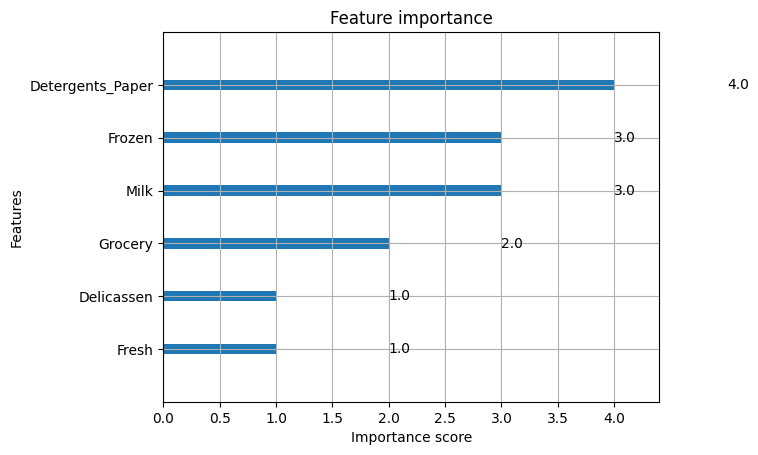

In [19]:
xgb.plot_importance(xgb_clf)
plt.show()